
## Branch Forescast



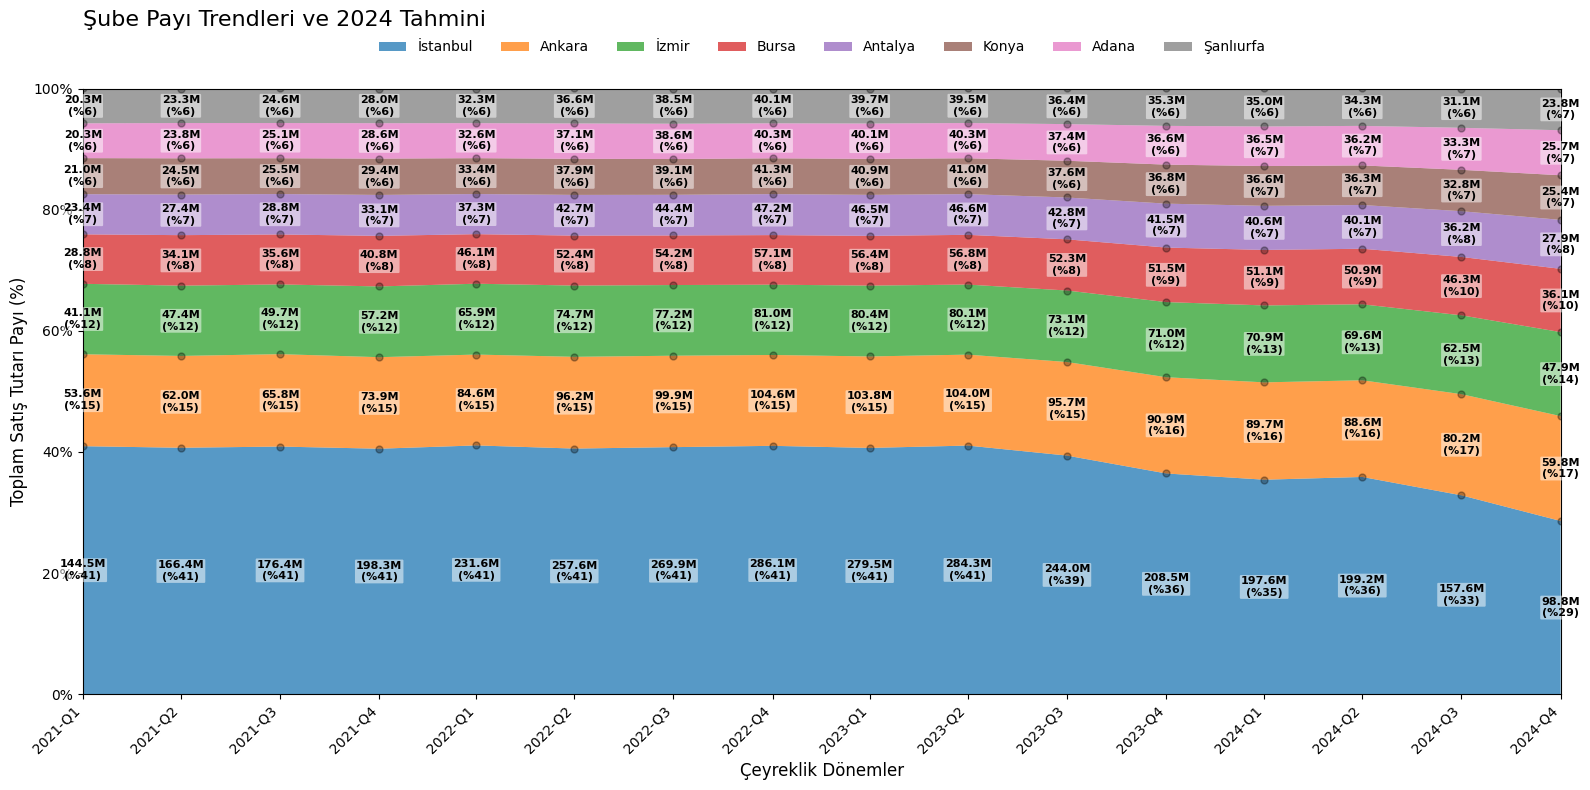

In [ ]:
# ==========================================
# 1. GEREKLİ KÜTÜPHANELER
# ==========================================
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from google.colab import auth
from google.cloud import bigquery
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 2. GOOGLE CLOUD BAĞLANTISI
# ==========================================
auth.authenticate_user()
client = bigquery.Client(project='superstore-analysis-496710')

# ==========================================
# 3. VERİYİ ÇEKME, TEMİZLEME VE FİLTRELEME
# ==========================================
# KRİTİK DÜZELTME: Henüz tamamlanmamış son ayı/çeyreği hariç tutuyoruz
# Not: Eğer verin örneğin 2023 Ağustos'ta bitiyorsa, aşağıdaki tarihe göre bir ayarla yapabilirsin.
# Şimdilik veri setinde en son "Tamamlanmış" ayın 2023 Temmuz (07) olduğunu varsayarak filtreliyorum.
query = """
    SELECT
        DATE(order_date) AS ds,
        branch_city,
        SUM(total_revenue) AS y
    FROM
        `superstore-analysis-496710.dbt_etilbac.Zaman Trendleri`
    WHERE
        branch_city IS NOT NULL
        -- EKSİK DÖNEM FİLTRESİ: Sadece tamamlanmış aylar
        -- (Aşağıdaki tarihi veritabanındaki son GÜVENİLİR ve TAM ay ile değiştir!)
        AND DATE(order_date) < '2023-08-01'
    GROUP BY
        ds, branch_city
    ORDER BY
        ds ASC
"""
df = client.query(query).to_dataframe()
df['y'] = df['y'].astype(float)

# ==========================================
# 4. EN ÇOK CİRO YAPAN 8 ŞEHRİ SEÇME
# ==========================================
top_cities = df.groupby('branch_city')['y'].sum().nlargest(8).index.tolist()
df = df[df['branch_city'].isin(top_cities)]

# ==========================================
# 5. KARARLI PROPHET MODELİ
# ==========================================
forecasts = {}
for city in top_cities:
    df_city = df[df['branch_city'] == city][['ds', 'y']]

    # DÜZELTME: Esnekliği düşürüp daha kararlı bir trend çizmesini sağladık (0.05 normal değerdir)
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.07
    )
    model.add_country_holidays(country_name='TR')
    model.fit(df_city)

    future = model.make_future_dataframe(periods=500)
    forecast = model.predict(future)

    forecasts[city] = forecast[['ds', 'yhat']].rename(columns={'yhat': city})

# ==========================================
# 6. TABLOLARI BİRLEŞTİRME VE TEMİZLEME
# ==========================================
merged_df = forecasts[top_cities[0]]
for city in top_cities[1:]:
    merged_df = pd.merge(merged_df, forecasts[city], on='ds', how='outer')

merged_df.set_index('ds', inplace=True)
merged_df.index = pd.to_datetime(merged_df.index)
merged_df = merged_df.clip(lower=0)

# ==========================================
# 7. ÇEYREKLİK HESAPLAMA (%100 Normalizasyon)
# ==========================================
quarterly_df = merged_df.resample('QE').sum()
percent_df = quarterly_df.div(quarterly_df.sum(axis=1), axis=0) * 100

percent_df = percent_df[percent_df.index.year >= 2021]
quarterly_df = quarterly_df[quarterly_df.index.year >= 2021]

# ==========================================
# 8. KUSURSUZ ÇİZİM İŞLEMİ (BOYALI ALAN)
# ==========================================
fig, ax = plt.subplots(figsize=(16, 8))

x_dates = percent_df.index
y_values = [percent_df[col] for col in percent_df.columns]
ax.stackplot(x_dates, y_values, labels=percent_df.columns, alpha=0.75, cmap='tab20')

cummulative_df = percent_df.cumsum(axis=1)
for column in cummulative_df.columns:
    ax.plot(cummulative_df.index, cummulative_df[column], marker='o', markersize=5, color='black', alpha=0.3, linewidth=0)

for i, date in enumerate(percent_df.index):
    y_cummulative = 0
    for j, city in enumerate(percent_df.columns):
        pct_val = percent_df.iloc[i, j]
        real_val = quarterly_df.iloc[i, j]

        if pct_val > 4:
            y_center = y_cummulative + (pct_val / 2)

            if real_val >= 1_000_000:
                label_text = f"{real_val/1_000_000:.1f}M\n(%{pct_val:.0f})"
            elif real_val >= 1_000:
                label_text = f"{real_val/1_000:.0f}K\n(%{pct_val:.0f})"
            else:
                label_text = f"{real_val:.0f}\n(%{pct_val:.0f})"

            ax.text(date, y_center, label_text, ha='center', va='center',
                    color='black', fontsize=8, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.1'))

        y_cummulative += pct_val

ax.set_title('Şube Payı Trendleri ve 2024 Tahmini', fontsize=16, loc='left', pad=45)
ax.set_xlabel('Çeyreklik Dönemler', fontsize=12)
ax.set_ylabel('Toplam Satış Tutarı Payı (%)', fontsize=12)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 100)
ax.set_xlim(percent_df.index.min(), percent_df.index.max())

labels = [f"{pd.to_datetime(x).year}-Q{pd.to_datetime(x).quarter}" for x in percent_df.index]
ax.set_xticks(percent_df.index)
ax.set_xticklabels(labels, rotation=45, ha='right')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=len(percent_df.columns), frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
# 9. TAHMİN SONUÇLARINI  AKTARMA
# ==========================================

import pandas_gbq
print("\nVeriler BigQuery formatına hazırlanıyor...")

# Geniş matrisi uzun formata çevirme
bq_export_df = merged_df.reset_index().melt(
    id_vars=['ds'],
    var_name='branch_city',
    value_name='predicted_revenue'  # İngilizce sütun adı
)

# Tarih sütununu
bq_export_df.rename(columns={'ds': 'date'}, inplace=True)  # İngilizce sütun adı
bq_export_df['date'] = pd.to_datetime(bq_export_df['date'])

hedef_tablo_id = 'dbt_etilbac.prophet_branch_forecasts'
proje_id = 'superstore-analysis-496710'

print(f"Hedef Tablo: {hedef_tablo_id}")
print("BigQuery'ye aktarım başlıyor...")

pandas_gbq.to_gbq(
    dataframe=bq_export_df,
    destination_table=hedef_tablo_id,
    project_id=proje_id,
    if_exists='replace',
)

print("✅ Tahmin verileri 'date', 'branch_city' ve 'predicted_revenue' sütunlarıyla BigQuery'ye yüklendi.")


Veriler BigQuery formatına hazırlanıyor...
Hedef Tablo: dbt_etilbac.prophet_branch_forecasts
BigQuery'ye aktarım başlıyor...


100%|██████████| 1/1 [00:00<00:00, 7244.05it/s]

✅ Tahmin verileri 'date', 'branch_city' ve 'predicted_revenue' sütunlarıyla BigQuery'ye yüklendi.


##matris öneri sistemi

In [ ]:
# ==========================================
# 1. GEREKLİ KÜTÜPHANELER VE BAĞLANTI
# ==========================================
import pandas as pd
from google.colab import auth
from google.cloud import bigquery
import warnings
warnings.filterwarnings('ignore')

auth.authenticate_user()
client = bigquery.Client(project='superstore-analysis-496710')

# ==========================================
# 2. ÜRÜN BAZLI (CROSS-SELL) VE KATEGORİLİ SQL SORGUSU
# ==========================================
query = """
WITH basket_data AS (
    SELECT
        od.order_id,

        -- DÜZELTME BURADA: Ürün isimlerinin tutulduğu sütunu bilmediğimiz için,
        -- şimdilik hata vermemesi adına ürün kodu olan 'item_id' sütununu kullanıyoruz.
        -- Gerçek ismi bulduğunuzda burayı örneğin 'c.product_name' olarak değiştirebilirsiniz.
        CAST(od.item_id AS STRING) AS urun_adi,

        -- KATEGORİ ADI
        c.category1 AS kategori_adi
    FROM
        `superstore-analysis-496710.analytics.stg_order_details` od
    JOIN
        `superstore-analysis-496710.analytics.stg_raw_categories` c
        ON od.item_id = c.itemid
),

-- 1. En çok satan 5 ana ÜRÜNÜ bul
item_totals AS (
    SELECT
        urun_adi,
        MAX(kategori_adi) AS kategori_adi,
        COUNT(DISTINCT order_id) as total_baskets
    FROM
        basket_data
    GROUP BY
        urun_adi
),
top_5_items AS (
    SELECT urun_adi, kategori_adi, total_baskets
    FROM item_totals
    ORDER BY total_baskets DESC
    LIMIT 5
),

-- 2. Aynı siparişteki ürün eşleşmelerini bul (Kategorileriyle birlikte)
co_occurrences AS (
    SELECT
        a.urun_adi AS ana_urun,
        a.kategori_adi AS ana_urun_kategori,
        b.urun_adi AS yan_urun,
        b.kategori_adi AS yan_urun_kategori,
        COUNT(DISTINCT a.order_id) AS co_occurrence_count
    FROM
        basket_data a
    JOIN
        basket_data b ON a.order_id = b.order_id AND a.urun_adi != b.urun_adi
    WHERE
        a.urun_adi IN (SELECT urun_adi FROM top_5_items)
    GROUP BY
        a.urun_adi, a.kategori_adi, b.urun_adi, b.kategori_adi
),

-- 3. Güven Yüzdesini (Confidence) Hesapla
confidence_calc AS (
    SELECT
        c.ana_urun,
        c.ana_urun_kategori,
        c.yan_urun,
        c.yan_urun_kategori,
        c.co_occurrence_count,
        (c.co_occurrence_count / t.total_baskets) * 100 AS confidence_pct,
        t.total_baskets AS ana_urun_toplam_satis
    FROM
        co_occurrences c
    JOIN
        top_5_items t ON c.ana_urun = t.urun_adi
),

-- 4. Her ana ürün için en iyi 3 yan ürünü sırala
ranked_cross_sells AS (
    SELECT
        ana_urun,
        ana_urun_kategori,
        ana_urun_toplam_satis,
        yan_urun,
        yan_urun_kategori,
        confidence_pct,
        ROW_NUMBER() OVER(PARTITION BY ana_urun ORDER BY confidence_pct DESC) as raf_sirasi
    FROM
        confidence_calc
)

-- 5. Sonucu Filtrele ve Getir
SELECT
    ana_urun,
    ana_urun_kategori,
    ana_urun_toplam_satis,
    raf_sirasi,
    yan_urun,
    yan_urun_kategori,
    ROUND(confidence_pct, 2) AS guven_yuzdesi_pct
FROM
    ranked_cross_sells
WHERE
    raf_sirasi <= 3
ORDER BY
    ana_urun_toplam_satis DESC, raf_sirasi ASC;
"""

df_raf_optimizasyonu = client.query(query).to_dataframe()

# ==========================================
# 3. KONSOL GÖRSELLEŞTİRMESİ
# ==========================================
if df_raf_optimizasyonu.empty:
    print("Veri bulunamadı. Sipariş detaylarında eşleşen ürün yok.")
else:
    ana_urunler_listesi = df_raf_optimizasyonu['ana_urun'].unique()

    print("🛒 MARKET RAF DİZİLİMİ STRATEJİSİ (TOP 5 ÜRÜN ID & İLK 3 ÇAPRAZ SATIŞ)\n")
    print("-" * 80)

    for urun in ana_urunler_listesi:
        alt_df = df_raf_optimizasyonu[df_raf_optimizasyonu['ana_urun'] == urun]
        ana_kategori = alt_df.iloc[0]['ana_urun_kategori']

        # Bu sefer Ürün ID'si yazacak (Örn: 84593)
        print(f"📦 ANA ÜRÜN KODU: {urun}  |  [Kategori: {ana_kategori}]")

        for _, row in alt_df.iterrows():
            print(f"   ↳ {row['raf_sirasi']}. Yan Raf Kodu: {row['yan_urun']}  |  [Kategori: {row['yan_urun_kategori']}]  👉  (Güven: %{row['guven_yuzdesi_pct']})")
        print("-" * 80)